# Day 08. Exercise 02
# Multiclass classification. One-hot encoding. Random forest

## 0. Imports

In [1]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, StandardScaler
import matplotlib.pyplot as plt
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.svm import SVC
from sklearn.multiclass import OneVsRestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

## 1. Preprocessing

1. Read the file [`checker-submits.csv`](https://drive.google.com/file/d/14voc4fNJZiLEFaZyd8nEG-lQt5JjatYw/view?usp=sharing).
2. Create a dataframe `df` with the columns: `uid`, `labname`, `numTrials`, `hour`, `dayofweek` where `hour` is extracted from the `timestamp` as well as the `dayofweek` (`0` is Monday, `6` is Sunday). We will try to predict the day of the week having data about which user made a commit for which lab at which hour and which try it was.
3. Using `OneHotEncoder()` transform your categorical features, delete from the dataframe the initial columns.
4. Use `StandardScaler()` and scale your continuous features.
5. Save the dataframe as `dayofweek.csv`.
6. Before trying out different algorithms, find out the accuracy of the naive algorithms – the one that predicts everything as the most popular class.

In [2]:
df = pd.read_csv("../data/checker_submits.csv")

In [3]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df['hour'] = df['timestamp'].dt.hour
df['dayofweek'] = df['timestamp'].dt.dayofweek
df = df[['uid', 'labname', 'numTrials', 'hour', 'dayofweek']]
df

,uid,labname,numTrials,hour,dayofweek
0,user_4,project1,1,5,4
1,user_4,project1,2,5,4
2,user_4,project1,3,5,4
3,user_4,project1,4,5,4
4,user_4,project1,5,5,4
...,...,...,...,...,...
1681,user_19,laba06s,9,20,3
1682,user_1,laba06s,6,20,3
1683,user_1,laba06s,7,20,3
1684,user_1,laba06s,8,20,3


In [4]:
encoder = OneHotEncoder(sparse_output=False, drop='first')
encoded_features = encoder.fit_transform(df[['uid', 'labname']])
encoded_columns = encoder.get_feature_names_out(['uid', 'labname'])
encoded_df = pd.DataFrame(encoded_features, columns=encoded_columns)

In [5]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(df[['numTrials', 'hour']])
scaled_df = pd.DataFrame(scaled_features, columns=['numTrials_scaled', 'hour_scaled'])

In [6]:
final_df = pd.concat([encoded_df, scaled_df, df[['dayofweek']]], axis=1)
final_df

,uid_user_1,uid_user_10,uid_user_11,uid_user_12,uid_user_13,uid_user_14,uid_user_15,uid_user_16,uid_user_17,uid_user_18,...,labname_lab05s,labname_laba04,labname_laba04s,labname_laba05,labname_laba06,labname_laba06s,labname_project1,numTrials_scaled,hour_scaled,dayofweek
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.788667,-2.562352,4
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.756764,-2.562352,4
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.724861,-2.562352,4
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.692958,-2.562352,4
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,-0.661055,-2.562352,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.533442,0.945382,3
1682,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.629151,0.945382,3
1683,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.597248,0.945382,3
1684,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,-0.565345,0.945382,3


In [7]:
final_df.to_csv("../data/dayofweek.csv", index=False)

In [8]:
most_common_day = df['dayofweek'].mode()[0]
naive_accuracy = (df['dayofweek'] == most_common_day).mean()
print(f"Naive Accuracy: {naive_accuracy:.4f}")

Naive Accuracy: 0.2349


## 2. Algorithms

### a. Logreg

1. Train logistic regression, for the baseline model use `random_state=21`, `fit_intercept=False`. 
2. Calculate the accuracy.
3. Write a function that draws the plot (`barh`) taking coefficients of any trained models, names of the features and the number of `top-n` most important features to display.
4. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model.
5. Remember that it is a multiclass classification and `coef_` returns a matrix, to calculate importance for a feature you need to sum all the individual feature importances for all the target values.

In [9]:
X = final_df.drop('dayofweek', axis=1)
y = final_df['dayofweek']

feature_names = X.columns.values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21, test_size=0.2)

In [10]:
model = LogisticRegression(random_state=21, fit_intercept=False, max_iter=200)
model.fit(X_train, y_train)

LogisticRegression(fit_intercept=False, max_iter=200, random_state=21)

In [11]:
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy of the baseline model: {accuracy:.2f}")

Accuracy of the baseline model: 0.60


In [12]:
def plot_feature_importance(coefficients, feature_names, top_n=10):
    importance = np.sum(np.abs(coefficients), axis=0)
    indices = np.argsort(importance)[-top_n:]
    top_features = importance[indices]
    top_feature_names = np.array(feature_names)[indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_feature_names, top_features, color='skyblue')
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Important Features")
    plt.gca().invert_yaxis()
    plt.show()

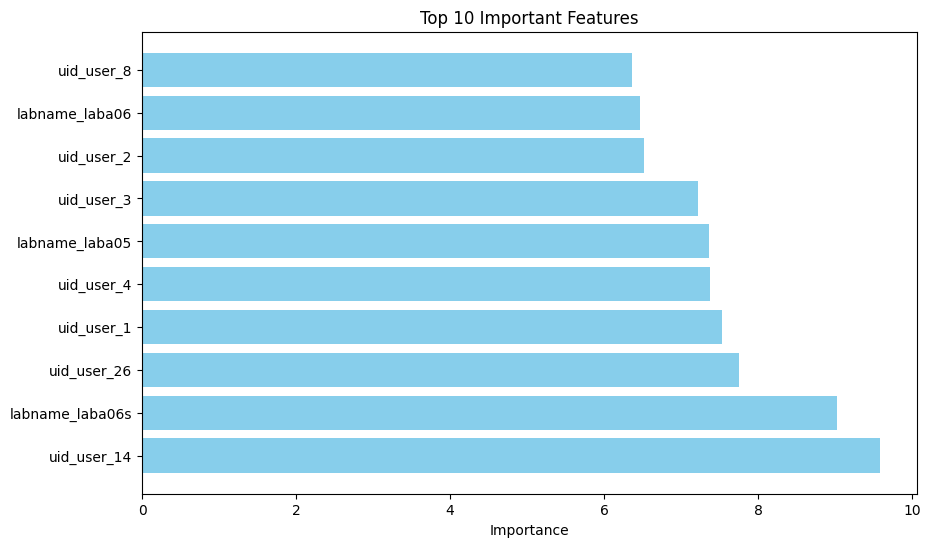

In [13]:
plot_feature_importance(model.coef_, feature_names, top_n=10)

### b. SVC

1. Train a `SVC` model, for the baseline model use parameters `kernel='linear'`, `probability=True`, `random_state=21`. 
2. Try different kernels, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model for the linear kernel *

*By default SVC uses “one vs one” strategy of the classification, thus in `coef_` it returns a matrix. To calculate importance for a feature you need to use [OneVsRestClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.multiclass.OneVsRestClassifier.html) over the SVC and sum all the individual feature importances for all the target values.

In [14]:
X = final_df.drop('dayofweek', axis=1)
y = final_df['dayofweek']

feature_names = X.columns.values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21, test_size=0.2)

In [15]:
svc_linear = SVC(kernel='linear', probability=True, random_state=21)
model_linear = OneVsRestClassifier(svc_linear)
model_linear.fit(X_train, y_train)

OneVsRestClassifier(estimator=SVC(kernel='linear', probability=True,
                                  random_state=21))

In [16]:
y_pred_linear = model_linear.predict(X_test)
accuracy_linear = accuracy_score(y_test, y_pred_linear)
print(f"Accuracy of the SVC model with linear kernel: {accuracy_linear:.2f}")

Accuracy of the SVC model with linear kernel: 0.63


In [17]:
kernels = ['linear', 'rbf', 'poly']
accuracies = {}

for kernel in kernels:
    svc_model = SVC(kernel=kernel, probability=True, random_state=21)
    model = OneVsRestClassifier(svc_model)
    model.fit(X_train, y_train)
    
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[kernel] = accuracy
    print(f"Accuracy of the SVC model with {kernel} kernel: {accuracy:.2f}")

Accuracy of the SVC model with linear kernel: 0.63
Accuracy of the SVC model with rbf kernel: 0.84
Accuracy of the SVC model with poly kernel: 0.85


In [18]:
def plot_feature_importance(coefficients, feature_names, top_n=10):
    importance = np.sum(np.abs(coefficients), axis=0)
    indices = np.argsort(importance)[-top_n:]
    top_features = importance[indices]
    top_feature_names = feature_names[indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_feature_names, top_features, color='skyblue')
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Important Features (Linear Kernel)")
    plt.gca().invert_yaxis()
    plt.show()

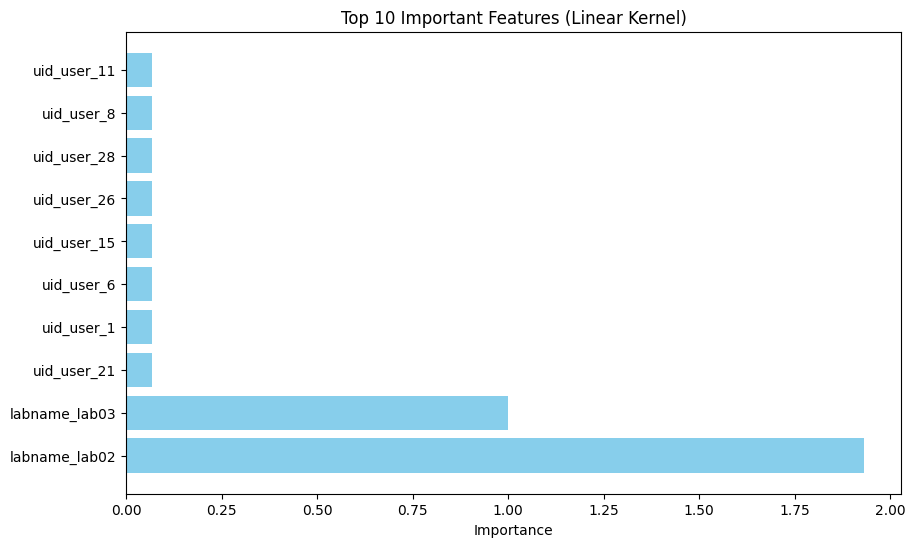

In [19]:
plot_feature_importance(model_linear.estimators_[0].coef_, feature_names, top_n=10)

### c. Decision tree

1. Train a `DecisionTreeClassifier` using for the baseline model `max_depth=4`, `random_state=21`. 
2. Try different values of `max_depth`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [20]:
X = final_df.drop('dayofweek', axis=1)
y = final_df['dayofweek']

feature_names = X.columns.values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21, test_size=0.2)

In [21]:
dt_model = DecisionTreeClassifier(max_depth=4, random_state=21)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=4, random_state=21)

In [22]:
y_pred_baseline = dt_model.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy of the baseline Decision Tree model (max_depth=4): {accuracy_baseline:.2f}")

Accuracy of the baseline Decision Tree model (max_depth=4): 0.56


In [23]:
max_depths = [1, 2, 3, 4, 5, 6, 7, 8]
accuracies = {}

for depth in max_depths:
    dt_model_depth = DecisionTreeClassifier(max_depth=depth, random_state=21)
    dt_model_depth.fit(X_train, y_train)
    
    y_pred = dt_model_depth.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    accuracies[depth] = accuracy
    print(f"Accuracy of Decision Tree model with max_depth={depth}: {accuracy:.2f}")

Accuracy of Decision Tree model with max_depth=1: 0.38
Accuracy of Decision Tree model with max_depth=2: 0.50
Accuracy of Decision Tree model with max_depth=3: 0.54
Accuracy of Decision Tree model with max_depth=4: 0.56
Accuracy of Decision Tree model with max_depth=5: 0.60
Accuracy of Decision Tree model with max_depth=6: 0.68
Accuracy of Decision Tree model with max_depth=7: 0.73
Accuracy of Decision Tree model with max_depth=8: 0.75


In [24]:
def plot_feature_importance(importances, feature_names, top_n=10):
    indices = np.argsort(importances)[-top_n:]
    top_features = importances[indices]
    top_feature_names = feature_names[indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_feature_names, top_features, color='skyblue')
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Important Features")
    plt.gca().invert_yaxis()
    plt.show()

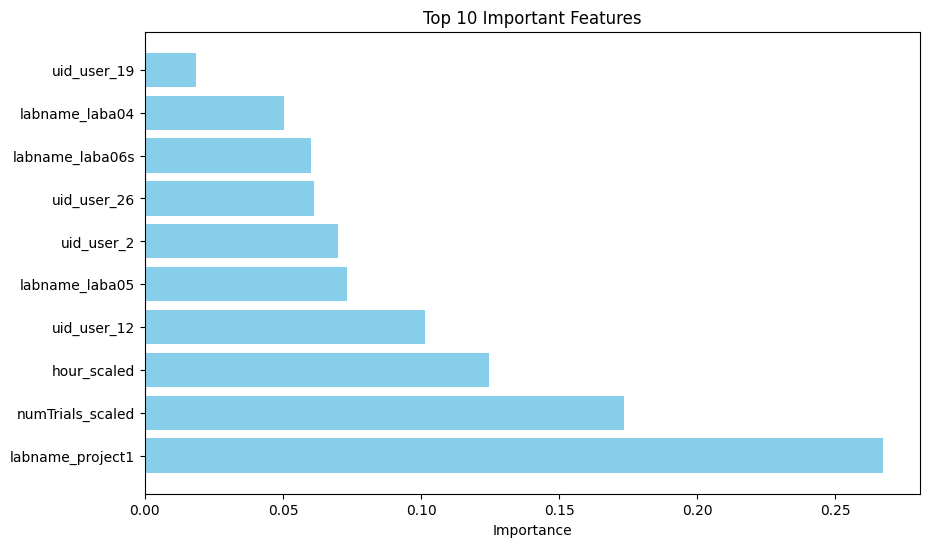

In [25]:
plot_feature_importance(dt_model.feature_importances_, feature_names, top_n=10)

### d. Random forest

In real life forest is a set of trees. The same thing is with machine learning. Random forest is a set of individual decision trees (check the documentation for more details).

1. Train a `RandomForestClassifier` using for the baseline model parameters `n_estimators=100`, `max_depth = 25`, `random_state=21`. 
2. Try different values of `max_depth` and `n_estimators`, calculate the accuracies.
3. Draw a plot (`barh`) for the baseline model with top-10 most important features (absolute value) for the trained model using the written function.

In [26]:
X = final_df.drop('dayofweek', axis=1)
y = final_df['dayofweek']

feature_names = X.columns.values

X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=21, test_size=0.2)

In [27]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=25, random_state=21)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=25, random_state=21)

In [28]:
y_pred_baseline = rf_model.predict(X_test)
accuracy_baseline = accuracy_score(y_test, y_pred_baseline)
print(f"Accuracy of the baseline Random Forest model (n_estimators=100, max_depth=25): {accuracy_baseline:.2f}")

Accuracy of the baseline Random Forest model (n_estimators=100, max_depth=25): 0.95


In [29]:
max_depths = [5, 10, 15, 20, 25, None]
n_estimators_options = [50, 100, 200]

accuracies = {}

for n_estimators in n_estimators_options:
    for max_depth in max_depths:
        rf_model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, random_state=21)
        rf_model.fit(X_train, y_train)
        
        y_pred = rf_model.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        accuracies[(n_estimators, max_depth)] = accuracy
        print(f"Accuracy of Random Forest model (n_estimators={n_estimators}, max_depth={max_depth}): {accuracy:.2f}")

Accuracy of Random Forest model (n_estimators=50, max_depth=5): 0.67
Accuracy of Random Forest model (n_estimators=50, max_depth=10): 0.88
Accuracy of Random Forest model (n_estimators=50, max_depth=15): 0.93
Accuracy of Random Forest model (n_estimators=50, max_depth=20): 0.94
Accuracy of Random Forest model (n_estimators=50, max_depth=25): 0.94
Accuracy of Random Forest model (n_estimators=50, max_depth=None): 0.94
Accuracy of Random Forest model (n_estimators=100, max_depth=5): 0.65
Accuracy of Random Forest model (n_estimators=100, max_depth=10): 0.87
Accuracy of Random Forest model (n_estimators=100, max_depth=15): 0.93
Accuracy of Random Forest model (n_estimators=100, max_depth=20): 0.93
Accuracy of Random Forest model (n_estimators=100, max_depth=25): 0.95
Accuracy of Random Forest model (n_estimators=100, max_depth=None): 0.95
Accuracy of Random Forest model (n_estimators=200, max_depth=5): 0.66
Accuracy of Random Forest model (n_estimators=200, max_depth=10): 0.88
Accuracy of

In [30]:
def plot_feature_importance(importances, feature_names, top_n=10):
    indices = np.argsort(importances)[-top_n:]
    top_features = importances[indices]
    top_feature_names = feature_names[indices]

    plt.figure(figsize=(10, 6))
    plt.barh(top_feature_names, top_features, color='skyblue')
    plt.xlabel("Importance")
    plt.title(f"Top {top_n} Important Features")
    plt.gca().invert_yaxis()
    plt.show()

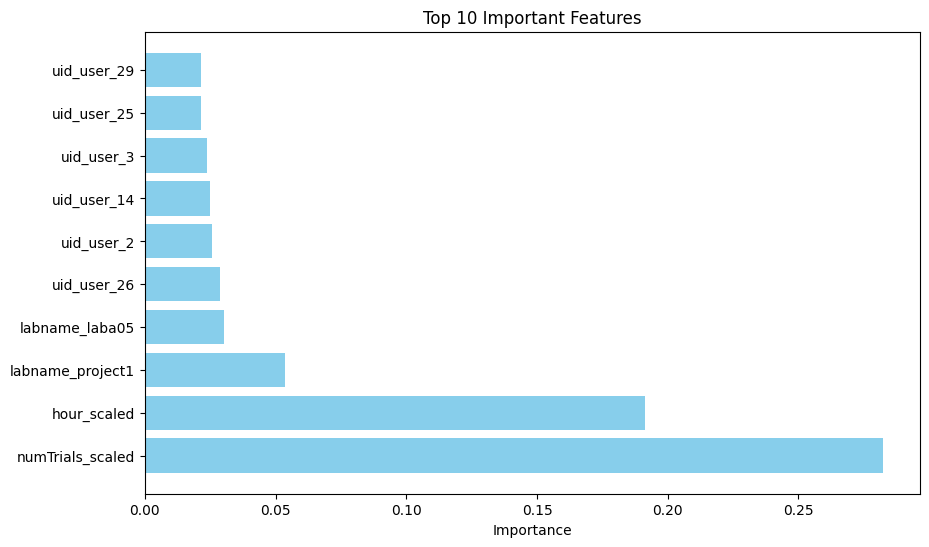

In [31]:
plot_feature_importance(rf_model.feature_importances_, feature_names, top_n=10)